<a href="https://colab.research.google.com/github/25wh1a0520-web/Nasscom/blob/main/Copy_of_U6_%E2%80%94_Probability_%26_Statistics_(Part_2)_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Core imports for the whole lab
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)


Setup complete. NumPy 2.1.3


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. PROBABILITY BY SIMULATION
# -----------------------------------------------------------

# P(A) = favourable outcomes / total outcomes.
# We can estimate it by simulating many trials.
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. THE ADDITION RULE (disjoint events)
# -----------------------------------------------------------

# Rolling a 1 OR a 2 — these events can't both happen (disjoint)
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [7]:
import random

counts = [0, 0, 0]

for _ in range(100_000):
    heads = random.randint(0,1) + random.randint(0,1)
    counts[heads] += 1

print("P(both heads):", counts[2]/100_000)
print("P(at least one head):", (counts[1]+counts[2])/100_000)
print("Sum:", sum(c/100_000 for c in counts))


P(both heads): 0.25213
P(at least one head): 0.75047
Sum: 1.0


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. CONDITIONAL PROBABILITY  P(A | B) = P(A and B) / P(B)
# -----------------------------------------------------------

rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')



P(6 | even) ~ 0.333  (true 1/3)


In [ ]:
# -----------------------------------------------------------
# 🔹 2B. TESTING FOR INDEPENDENCE
# -----------------------------------------------------------

# Two events are independent if P(A|B) == P(A).
# 'roll > 3' and 'roll is even' -> are they independent?
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))


P(A)      = 0.5
P(A | B)  = 0.665
Independent? False


In [27]:

rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)
less_than_4 = rolls[rolls < 4]
p_odd_given_less4 = np.mean(less_than_4 % 2 == 1)
print("P(odd | <4):", p_odd_given_less4)

# 2. P(roll < 4)
p_less4 = np.mean(rolls < 4)
print("P(<4):", p_less4)

# 3. Compare P(odd | <4) with P(odd) overall
p_odd = np.mean(rolls % 2 == 1)
print("P(odd):", p_odd)

print("Independent?", np.isclose(p_odd_given_less4, p_odd))


P(odd | <4): 0.6692780861167325
P(<4): 0.49909
P(odd): 0.50055
Independent? False


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. THE MEDICAL-TEST PROBLEM (by formula)
# -----------------------------------------------------------

# Disease affects 1% of people; test is 99% accurate.
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')



P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [ ]:
# -----------------------------------------------------------
# 🔹 3B. THE SAME ANSWER BY SIMULATION (sanity check)
# -----------------------------------------------------------

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))


Simulated P(sick | positive) = 0.497


In [15]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

# 2. P('free') via total probability
p_ham = 1 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print("P('free') =", p_free)

# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print("P(spam | 'free') =", p_spam_given_free)


P('free') = 0.16
P(spam | 'free') = 0.75


In [22]:

import numpy as np
from scipy import stats

# -----------------------------------------------------------
# 4A. BERNOULLI & POISSON (Discrete Distributions)
# -----------------------------------------------------------

# Bernoulli: a single yes/no trial with probability p = 0.3
bern = stats.bernoulli(p=0.3).rvs(size=10_000, random_state=42)

print("Bernoulli(0.3) mean ~", round(bern.mean(), 3))
print("True mean =", 0.3)

# Poisson: number of events occurring in an interval
# with average rate (lambda) = 4
pois = stats.poisson(mu=4).rvs(size=10_000, random_state=42)

print("Poisson(4) mean ~", round(pois.mean(), 3))
print("True mean =", 4)


Bernoulli(0.3) mean ~ 0.289
True mean = 0.3
Poisson(4) mean ~ 3.984
True mean = 4


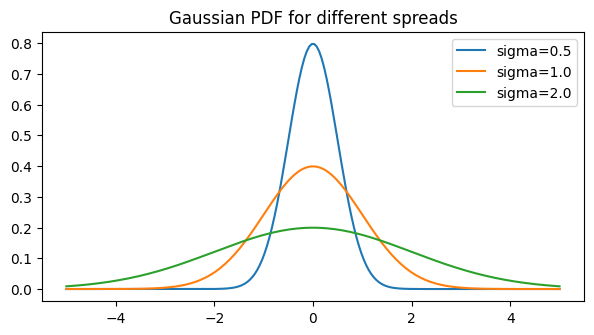

In [25]:

# -----------------------------------------------------------
# 🔹 4B. THE GAUSSIAN (normal) — plot the bell curve
# -----------------------------------------------------------

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Poisson(2) sample mean = 2.006
True mean = 2


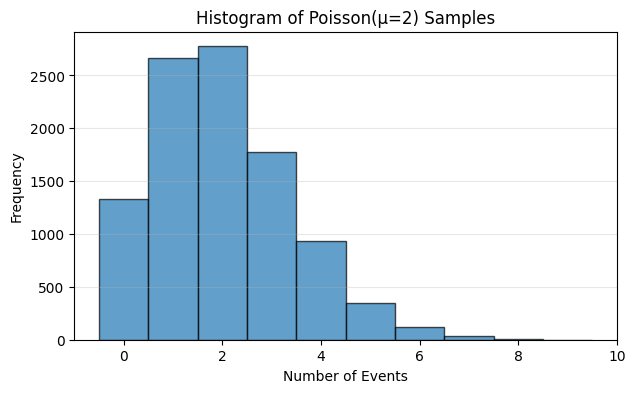

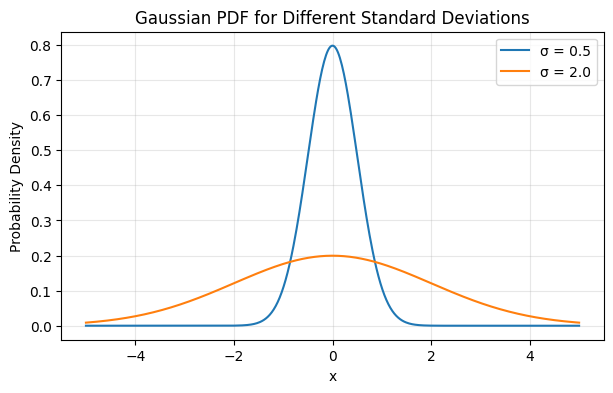

In [26]:
# -----------------------------------------------------------
# LAB EXERCISE 4 — Simulate & Plot Distributions
# -----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------------------------------------
# 1. Poisson(mu=2) samples + mean
# -----------------------------------------------------------

samples = stats.poisson(mu=2).rvs(size=10_000, random_state=42)

print("Poisson(2) sample mean =", round(samples.mean(), 3))
print("True mean = 2")


# -----------------------------------------------------------
# 2. Histogram of the samples
# -----------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.hist(
    samples,
    bins=np.arange(samples.min() - 0.5, samples.max() + 1.5, 1),
    edgecolor="black",
    alpha=0.7
)

plt.title("Histogram of Poisson(μ=2) Samples")
plt.xlabel("Number of Events")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.show()


# -----------------------------------------------------------
# 3. Gaussian PDF for two sigmas on one plot
# -----------------------------------------------------------

x = np.linspace(-5, 5, 500)

plt.figure(figsize=(7, 4))

for sigma in [0.5, 2.0]:
    y = stats.norm(loc=0, scale=sigma).pdf(x)
    plt.plot(x, y, label=f"σ = {sigma}")

plt.title("Gaussian PDF for Different Standard Deviations")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [ ]:
# -----------------------------------------------------------
# 🔹 5A. ENTROPY — how uncertain is a distribution?
# -----------------------------------------------------------

from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [19]:
# -----------------------------------------------------------
# 🔹 5B. KL DIVERGENCE — how far is Q from P?
# -----------------------------------------------------------

P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')


D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [ ]:
# -----------------------------------------------------------
# 🔹 5C. MUTUAL INFORMATION — which feature is most informative?
# -----------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')


0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [18]:
from scipy.stats import entropy
import numpy as np

# 1. Entropy of a fair 4-sided and 6-sided die
H4 = entropy([1/4] * 4, base=2)
H6 = entropy([1/6] * 6, base=2)

print("Entropy of 4-sided die:", H4)
print("Entropy of 6-sided die:", H6)

# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

KL = entropy(P, Q, base=2)
print("KL divergence D(P || Q):", KL)

# 3. Most / least informative iris feature (from 5C)
# Most informative: petal length
# Least informative: sepal width


Entropy of 4-sided die: 2.0
Entropy of 6-sided die: 2.584962500721156
KL divergence D(P || Q): 0.11870910076930725
